# Global Conflict Analysis: Descriptive Insights from 1979–2021
## Second Notebook: Objective

Building on the high-level exploratory analysis conducted in the first notebook, this second notebook focuses on examining patterns, relationships, and comparative dynamics of global conflict events in greater depth.

The primary goal is to perform an exploratory, analytical assessment to identify meaningful patterns, correlations, and anomalies in conflict data, rather than producing definitive actionable recommendations at this stage. Key analyses include exploring correlations between conflict severity and media coverage, detecting temporal and regional trends in high-intensity conflicts, comparing patterns across countries and regions, and identifying shifts in the nature of conflict events over decades.

Analytical methods include bivariate and multivariate descriptive statistics, correlation matrices, and advanced visualizations complemented by geospatial mapping for regional comparisons.

**Author**: J-F Jutras  
**Date**: November 2025  
**Dataset**: Global Conflict Events Dataset – Kaggle (1979–2021, preprocessed)



## 2.1-Data Loading and Overview

In [1]:
import pandas as pd
import os

#Import original file
dataset_dir = '/kaggle/input/gdelt-conflict-events-1979-2021'
csv_path = os.path.join(dataset_dir, 'gdelt_conflict_1_0.csv')

df_original = pd.read_csv(csv_path)

print(df_original.head())

   Year CountryCode CountryName  SumEvents  TotalEvents  NormalizedEvents1000  \
0  1979          CH       China        350        33541             10.434990   
1  1979          HR     Croatia         14          714             19.607843   
2  1979          SU       Sudan         16         1354             11.816839   
3  1979          SY       Syria         71         3119             22.763706   
4  1979          GM     Germany         33         6615              4.988662   

   EventRootCode EventRootDescr  EventCode  \
0             19          FIGHT        193   
1             19          FIGHT        190   
2             17         COERCE        173   
3             19          FIGHT        193   
4             17         COERCE        172   

                                          EventDescr  GoldsteinScale  \
0            Fight with small arms and light weapons           -10.0   
1  Use conventional military force, not specified...           -10.0   
2       Arrest, deta

In [2]:
#Import file with transformed features
file_path = "/kaggle/input/global-conflicts-preprocessed/global_conflict_full_boxcox.csv"
df = pd.read_csv(file_path)

#Quick check
print(df.head())
print(df.info())

   Year CountryCode CountryName  SumEvents  TotalEvents  NormalizedEvents1000  \
0  1979          CH       China        350        33541              2.340348   
1  1979          HR     Croatia         14          714              2.968176   
2  1979          SU       Sudan         16         1354              2.464184   
3  1979          SY       Syria         71         3119              3.116617   
4  1979          GM     Germany         33         6615              1.604904   

   EventRootCode EventRootDescr  EventCode  \
0             19          FIGHT        193   
1             19          FIGHT        190   
2             17         COERCE        173   
3             19          FIGHT        193   
4             17         COERCE        172   

                                          EventDescr  GoldsteinScale  \
0            Fight with small arms and light weapons           -10.0   
1  Use conventional military force, not specified...           -10.0   
2       Arrest, deta

## 2.2-Conflict Types and Severity over Time

This section will explore both the distribution of event categories and their temporal dynamics. The analysis will begin by identifying the most common conflict types using frequency counts. Next, the severity of these events, measured by the GoldsteinScale, will be examined across decades to detect long-term trends, shifts in intensity, and potential escalation patterns. This includes computing yearly averages and medians, analyzing severity by event category, and visualizing temporal evolution through line charts and boxplots. Together, these steps will provide a comprehensive view of how different forms of conflict have manifested and intensified over time.

In [3]:
#Number of specific event descriptions per root category
root_to_specific_counts = df.groupby('EventRootDescr')['EventDescr'].nunique().sort_values(ascending = False)

print(root_to_specific_counts)

EventRootDescr
ASSAULT                             13
COERCE                              12
FIGHT                                7
USE UNCONVENTIONAL MASS VIOLENCE     3
Name: EventDescr, dtype: int64


In [4]:
#Severity distribution by conflict type
import pandas as pd

severity_by_type = df.groupby('EventRootDescr')['GoldsteinScale'].describe()
print(severity_by_type[['mean', '50%', 'min', 'max']].head(10))

                                      mean   50%   min  max
EventRootDescr                                             
ASSAULT                          -9.361275  -9.0 -10.0 -8.0
COERCE                           -6.516677  -5.0  -9.2 -5.0
FIGHT                            -9.827852 -10.0 -10.0 -9.5
USE UNCONVENTIONAL MASS VIOLENCE -9.911542 -10.0 -10.0 -9.5


In [5]:
#Get the list of root categories (EventRootDescr - EventDescr)
roots = df['EventRootDescr'].unique()

tables = {}

for root in roots:
    subset = (
        df[df['EventRootDescr'] == root]
        .groupby('EventDescr')['GoldsteinScale']
        .mean()
        .reset_index()
        .sort_values('GoldsteinScale')
    )
    tables[root] = subset
    print(f"\n===== {root} =====\n")
    print(subset)


===== FIGHT =====

                                          EventDescr  GoldsteinScale
0                              Employ aerial weapons           -10.0
1                     Fight with artillery and tanks           -10.0
2            Fight with small arms and light weapons           -10.0
5  Use conventional military force, not specified...           -10.0
3                Impose blockade, restrict movement             -9.5
4                                   Occupy territory            -9.5
6                                 Violate ceasefire             -9.5

===== COERCE =====

                                           EventDescr  GoldsteinScale
3                                 Confiscate property            -9.2
10      Seize or damage property, not specified below            -9.2
4                                    Destroy property            -9.2
11                Use tactics of violent repression              -9.0
2                        Coerce, not specified below     

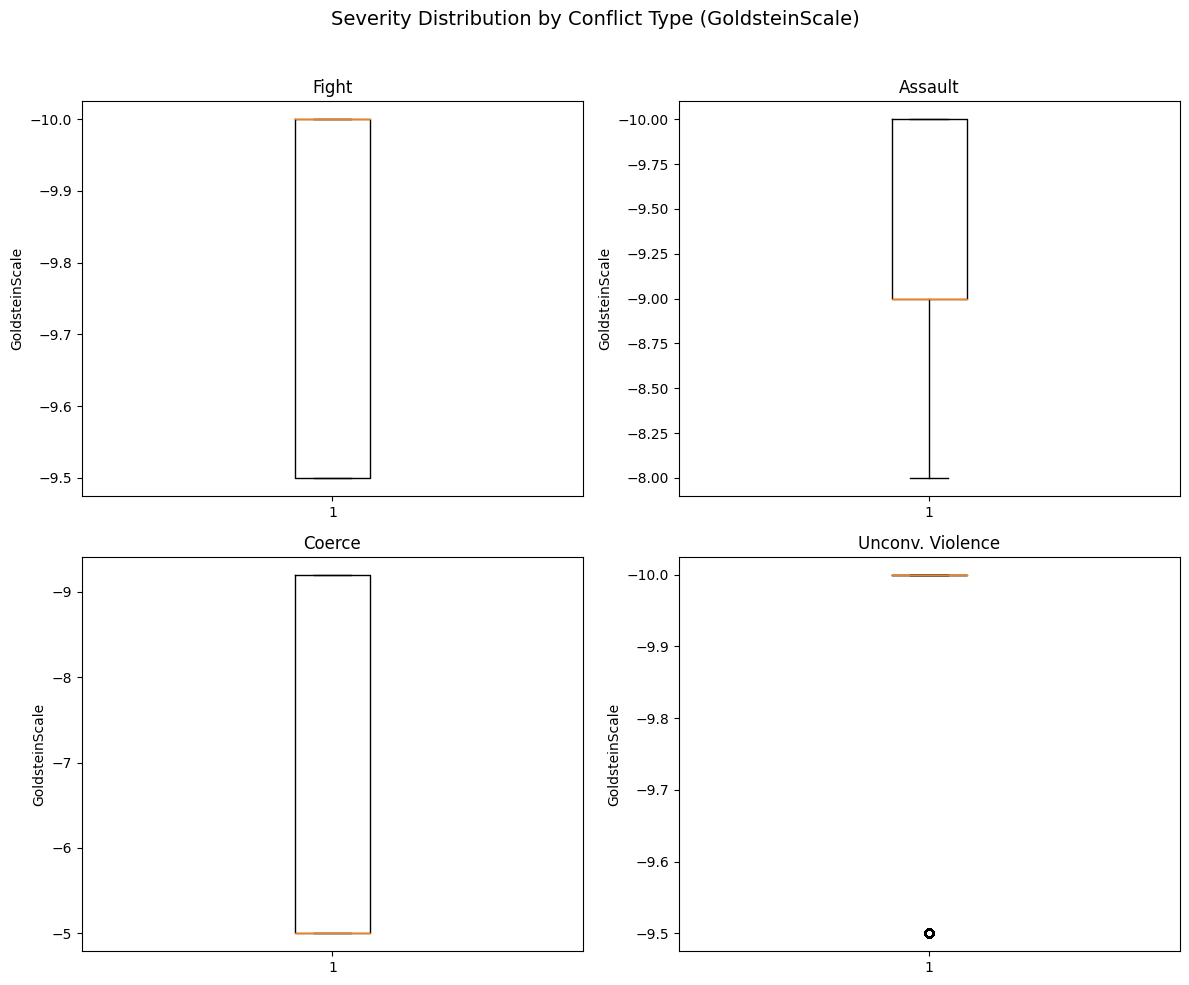

In [6]:
import matplotlib.pyplot as plt

#Ignore warnings for display purposes
import warnings
warnings.filterwarnings("ignore")

#Shorter labels for readability
label_mapping = {
    "USE UNCONVENTIONAL MASS VIOLENCE": "Unconv. Violence",
    "FIGHT": "Fight",
    "ASSAULT": "Assault",
    "COERCE": "Coerce"
}

df['EventRootDescr_short'] = df['EventRootDescr'].apply(
    lambda x: label_mapping.get(x, x)
)

#Unique ordered categories
categories = ["Fight", "Assault", "Coerce", "Unconv. Violence"]

#Prepare the layout
fig, axes = plt.subplots(2, 2, figsize = (12, 10))

axes = axes.flatten()

for ax, cat in zip(axes, categories):
    subset = df[df['EventRootDescr_short'] == cat]['GoldsteinScale']
    ax.boxplot(subset, vert=True)
    ax.set_title(cat)
    ax.set_ylabel("GoldsteinScale")
    ax.invert_yaxis()

plt.suptitle("Severity Distribution by Conflict Type (GoldsteinScale)", fontsize = 14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

EventRootDescr_short
Coerce              69145
Assault             55967
Fight               43271
Unconv. Violence     8049
Name: count, dtype: int64


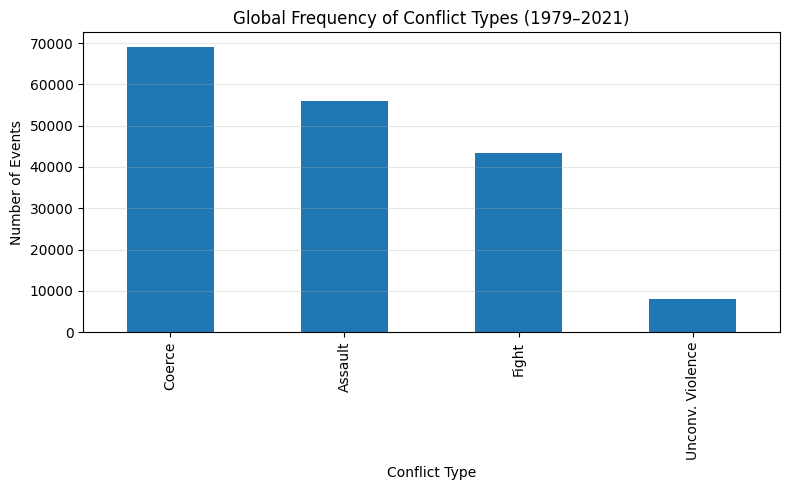

In [7]:
#Global frequency of each conflict type
type_counts = df['EventRootDescr_short'].value_counts().sort_values(ascending=False)
print(type_counts)

#Barplot
plt.figure(figsize=(8,5))
type_counts.plot(kind='bar')
plt.title("Global Frequency of Conflict Types (1979–2021)")
plt.xlabel("Conflict Type")
plt.ylabel("Number of Events")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

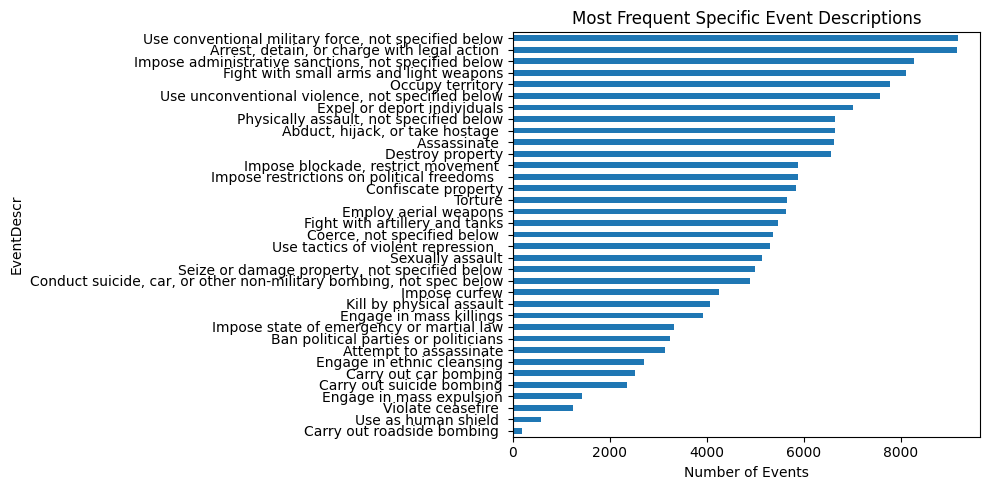

In [8]:
# Most frequent specific event descriptions
top_specific = df['EventDescr'].value_counts()

#Horizontal barplot
plt.figure(figsize=(10,5))
top_specific.sort_values().plot(kind='barh')
plt.title("Most Frequent Specific Event Descriptions")
plt.xlabel("Number of Events")
plt.tight_layout()
plt.show()

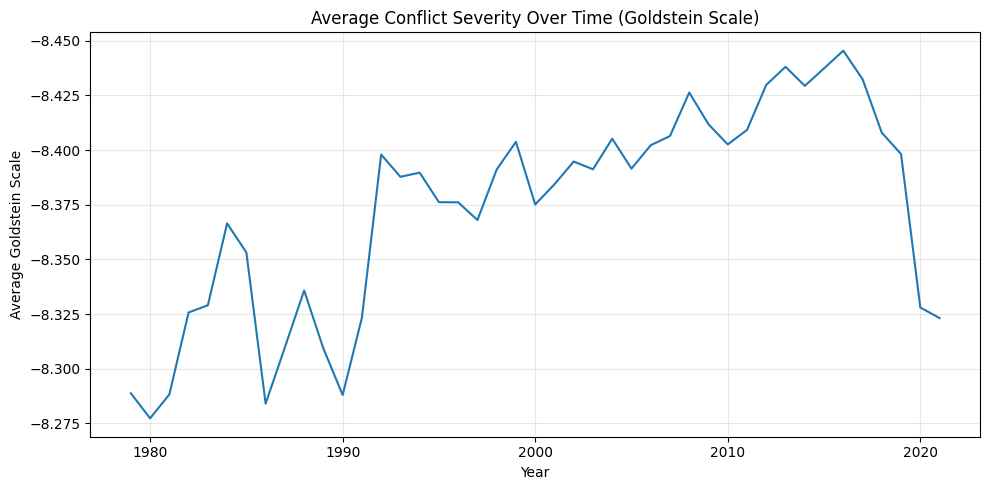

In [9]:
#Temporal Evolution of Severity
yearly_severity = df.groupby('Year')['GoldsteinScale'].mean()

plt.figure(figsize = (10, 5))
plt.plot(yearly_severity.index, yearly_severity.values)
plt.title("Average Conflict Severity Over Time (Goldstein Scale)")
plt.xlabel("Year")
plt.ylabel("Average Goldstein Scale")
plt.grid(True, alpha = 0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

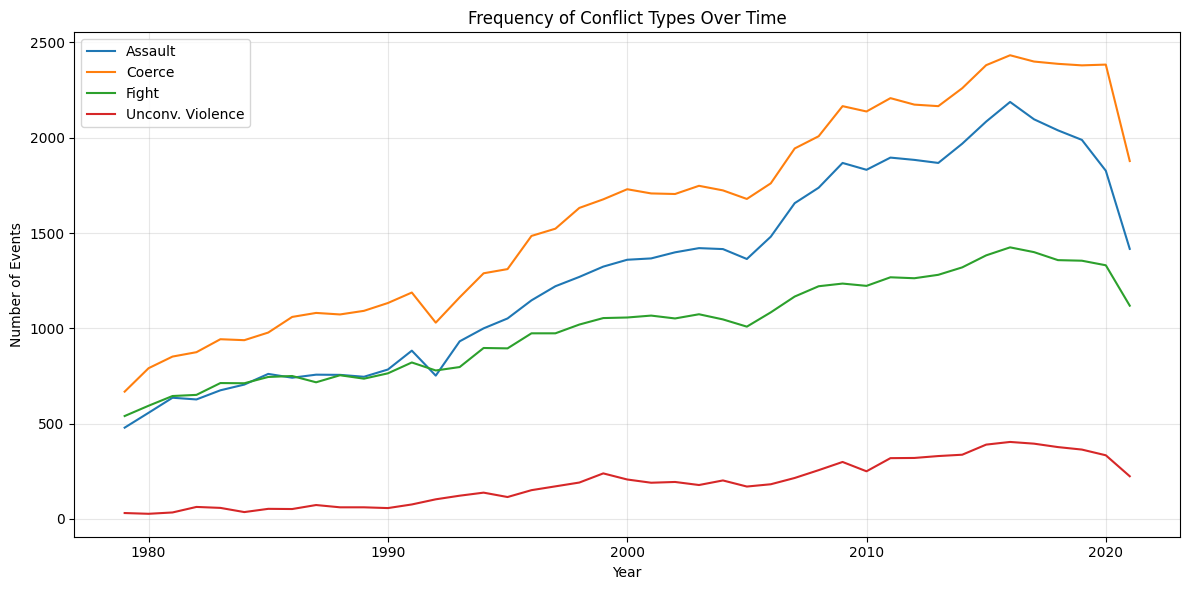

In [10]:
#Frequency of Conflict Types Over Time

#Count how many events of each conflict type occur per year
type_frequency = df.groupby(['Year', 'EventRootDescr_short']).size().reset_index(name = 'Count')

#Pivot into a wide table for plotting
type_freq_pivot = type_frequency.pivot(index = 'Year', columns = 'EventRootDescr_short', values = 'Count').fillna(0)

#Plot the frequency of each conflict type across time
plt.figure(figsize = (12,6))

for col in type_freq_pivot.columns:
    plt.plot(type_freq_pivot.index, type_freq_pivot[col], label = col)

plt.title("Frequency of Conflict Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

### Summary

**Structure of conflict types**

We counted how many detailed event descriptions (“EventDescr”) fall under each root category (“EventRootDescr”):

- **ASSAULT:** 13 subtypes  
- **COERCE:** 12 subtypes  
- **FIGHT:** 7 subtypes  
- **UNCONVENTIONAL MASS VIOLENCE:** 3 subtypes  

This establishes the internal diversity of each category.

**Severity per conflict type**

We then computed mean, median, and range of GoldsteinScale for each root category:

- **FIGHT:** extremely severe, low variance (mean ≈ –9.83)  
- **UNCONVENTIONAL MASS VIOLENCE:** equally severe (mean ≈ –9.91)  
- **ASSAULT:** very severe but more heterogeneous (mean ≈ –9.36)  
- **COERCE:** significantly less severe (mean ≈ –6.52), mixing institutional and destructive actions  

These results show that each category reflects a distinct violence intensity profile.

**Severity at the Subtype Level**

We computed severity for each *EventRootDescr × EventDescr* pair:

- **FIGHT** and **UNCONVENTIONAL MASS VIOLENCE** subtypes were almost uniformly between –9.5 and –10.  
- **ASSAULT** covered a broader range (–8 to –10).  
- **COERCE** had the widest spread (–5 to –9.2).  

Differences between categories therefore arise from their internal composition.

**Frequency Over Time (1979–2021)**

Yearly event counts were calculated for each category:

- All types increase gradually from 1979 to a peak in **2014–2016**.  
- **COERCE** is consistently the most frequent.  
- **UNCONVENTIONAL MASS VIOLENCE** grows the fastest relative to its baseline.  
- All types decline after 2016.

This captures the temporal evolution of conflict activity.

**Evolution of Average Severity**

We computed yearly average GoldsteinScale:

- Severity is relatively stable but shows a slight downward trend (≈ –8.28 → ≈ –8.44).  
- The most severe years occur between **2012–2016**, overlapping with frequency peaks.

**Answer to our question about conflict types and severity**

Conflict categories differ clearly in their severity profiles:  
   - *FIGHT* and *UNCONVENTIONAL MASS VIOLENCE* are the most severe.  
   - *ASSAULT* is severe but more variable.  
   - *COERCE* mixes low- and high-intensity actions.

Their frequencies evolve differently:  
   - All increase until mid-2010s; *COERCE* is always the most common.  
   - *UNCONVENTIONAL MASS VIOLENCE* rises fastest relative to its base rate.  
   - All decline after 2016.

Average severity grows slightly more negative over time, with a peak in violence intensity during 2012–2016.

## 2.3-Conflict Severity and Media Coverage

### 2.3.1-Descriptive Statistics

In [11]:
#Descriptive statistics: average media coverage by conflict type and event severity 
severity_summary = df.groupby(['EventRootDescr_short', 'GoldsteinScale'])['AvgNumMentions'].describe()
print(severity_summary[['count', 'mean', '50%', 'min', 'max']])

                                       count      mean       50%       min  \
EventRootDescr_short GoldsteinScale                                          
Assault              -10.0           20612.0  1.506156  1.501983  0.000000   
                     -9.5             6649.0  1.589414  1.551940  0.000000   
                     -9.0            24989.0  1.551756  1.530454  0.000000   
                     -8.0             3717.0  1.366302  1.359669  0.000000   
Coerce               -9.2            17347.0  1.595560  1.584514  0.000000   
                     -9.2               26.0  1.978048  1.933069  1.369338   
                     -9.0             5296.0  1.741544  1.727531  0.000000   
                     -7.0             5360.0  1.640893  1.643023  0.000000   
                     -5.0            41116.0  1.599374  1.567694  0.000000   
Fight                -10.0           28373.0  1.564731  1.521369  0.000000   
                     -9.5            14898.0  1.610913  1.594253

This table shows basic descriptive statistics (count, mean, median, min, max) of average media coverage (`AvgNumMentions`) for each conflict type (`EventRootDescr_short`) and GoldsteinScale value:

- Mean and median mentions are very similar across severity levels within each conflict type.
- Minimum mentions are often zero, indicating many events receive no media coverage.
- Maximum mentions are outliers and not representative of typical coverage.
- Overall, media attention does not noticeably increase with higher conflict severity, confirming that coverage is largely independent of how severe an event is.


### 2.3.2-Spearman Correlations

We will start by evaluating the relationships between key variables using **Spearman correlations**, which are appropriate for assessing monotonic relationships between a continuous variable (AvgNumMentions) and a discrete variable (Goldstein).

Spearman correlations are computed on the ranks of the data, making them robust to skewed distributions and extreme values. This approach allows us to capture meaningful associations without imposing strict normality assumptions.

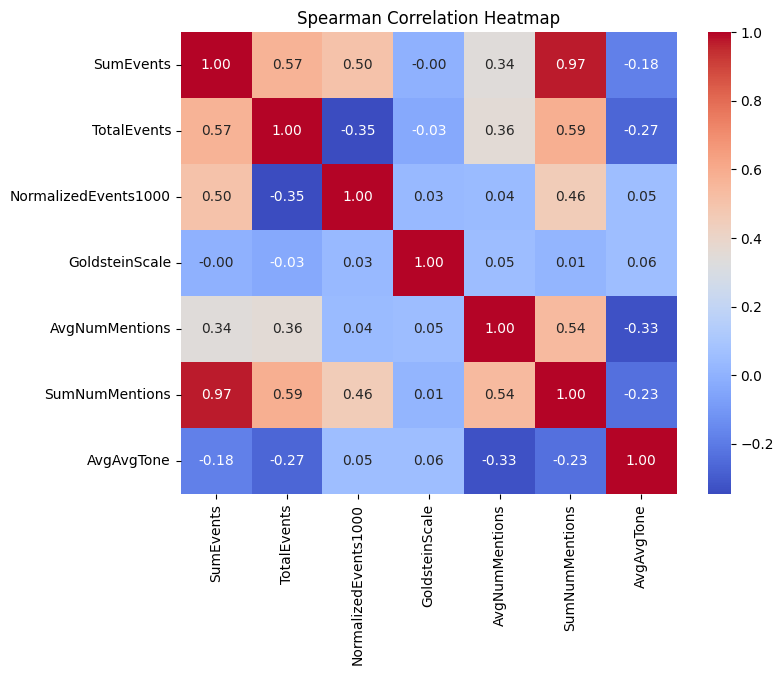

In [12]:
import numpy as np
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)

vars_spearman = ['SumEvents', 'TotalEvents', 'NormalizedEvents1000',
                 'GoldsteinScale', 'AvgNumMentions', 'SumNumMentions', 'AvgAvgTone']

#Compute correlations
spearman_corr = df[vars_spearman].corr(method='spearman')

#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Spearman Correlation Heatmap")
plt.show()

We analyzed the relationship between **conflict severity** (`GoldsteinScale`) and **media coverage** (`AvgNumMentions` and `SumNumMentions`) using **Spearman correlations** at the global level. 

The results show that the correlations are **very weak** (≈ 0.050 for `AvgNumMentions`; ≈ 0.012 for `SumNumMentions_log`), indicating that **the severity of conflict events is largely independent of how much they are covered in the media**. 

In contrast, media coverage is **strongly correlated with the number of events** (`SumEvents` and `TotalEvents`), reflecting that highly covered events tend to occur in years or countries with more conflict events overall, rather than being inherently more severe. 

Similarly, the **average media tone** (`AvgAvgTone`) shows only weak correlations with severity, although it slightly trends more negative for events with higher coverage. 

At the global level, it seems that media attention is driven primarily by the **volume of conflict events**, not their **severity**. To refine this analysis, we will now examine the data by continent. Aggregating the events regionally will allow us to identify whether the relationship between conflict severity and media coverage differs across continents, highlighting potential geographic patterns that are not visible at the global level.

### 2.3.3-Correlations by continent

In [13]:
#Map countries to continents
country_to_continent = {
    "W. Sahara": "Africa",
    "United States": "North America",
    "Dem. Rep. Congo": "Africa",
    "Dominican Rep.": "North America",
    "Bahamas": "North America",
    "Falkland Is.": "South America",
    "Fr. S. Antarctic Lands": "Antarctica",
    "Côte d'Ivoire": "Africa",
    "Central African Rep.": "Africa",
    "Congo": "Africa",
    "Eq. Guinea": "Africa",
    "eSwatini": "Africa",
    "Palestine": "Asia",
    "Korea, North": "Asia",
    "South Korea": "Asia",
    "Solomon Is.": "Oceania",
    "Czechia": "Europe",
    "N. Cyprus": "Asia",
    "Somaliland": "Africa",
    "Bosnia and Herz.": "Europe",
    "North Macedonia": "Europe",
    "S. Sudan": "Africa",
    "China": "Asia",
    "Croatia": "Europe",
    "Sudan": "Africa",
    "Syria": "Asia",
    "Germany": "Europe",
    "United Kingdom": "Europe",
    "Israel": "Asia",
    "Angola": "Africa",
    "Russia": "Asia",
    "Central African Republic": "Africa",
    "Uganda": "Africa",
    "Zimbabwe": "Africa",
    "Egypt": "Africa",
    "Sweden": "Europe",
    "Albania": "Europe",
    "Panama": "North America",
    "France": "Europe",
    "Mexico": "North America",
    "Nicaragua": "North America",
    "South Africa": "Africa",
    "Mozambique": "Africa",
    "Slovakia": "Europe",
    "Fiji": "Oceania",
    "Iran": "Asia",
    "Afghanistan": "Asia",
    "Burma": "Asia",
    "Myanmar": "Asia",
    "Taiwan": "Asia",
    "Azerbaijan": "Asia",
    "Uzbekistan": "Asia",
    "Libya": "Africa",
    "Sri Lanka": "Asia",
    "El Salvador": "North America",
    "Pakistan": "Asia",
    "Italy": "Europe",
    "Turkey": "Asia",
    "Honduras": "North America",
    "United Arab Emirates": "Asia",
    "Czech Republic": "Europe",
    "Congo, Democratic Republic of the": "Africa",
    "Saint Vincent and the Grenadines": "North America",
    "Ireland": "Europe",
    "Macedonia": "Europe",
    "Vietnam": "Asia",
    "Korea, South": "Asia",
    "Bahamas, The": "North America",
    "Laos": "Asia",
    "Greece": "Europe",
    "Bangladesh": "Asia",
    "Iraq": "Asia",
    "Cambodia": "Asia",
    "Dominican Republic": "North America",
    "Kuwait": "Asia",
    "Tanzania": "Africa",
    "Ukraine": "Europe",
    "Chad": "Africa",
    "Hungary": "Europe",
    "Philippines": "Asia",
    "Belgium": "Europe",
    "Costa Rica": "North America",
    "Saudi Arabia": "Asia",
    "Botswana": "Africa",
    "Haiti": "North America",
    "Morocco": "Africa",
    "Nigeria": "Africa",
    "Argentina": "South America",
    "Hong Kong": "Asia",
    "Austria": "Europe",
    "Malawi": "Africa",
    "Ghana": "Africa",
    "Gaza Strip": "Asia",
    "Namibia": "Africa",
    "Chile": "South America",
    "Spain": "Europe",
    "India": "Asia",
    "Yemen": "Asia",
    "Jordan": "Asia",
    "Guatemala": "North America",
    "Estonia": "Europe",
    "Romania": "Europe",
    "Jamaica": "North America",
    "Mongolia": "Asia",
    "Lebanon": "Asia",
    "Zambia": "Africa",
    "Liberia": "Africa",
    "Denmark": "Europe",
    "Seychelles": "Africa",
    "Mali": "Africa",
    "Poland": "Europe",
    "Somalia": "Africa",
    "Guyana": "South America",
    "Lesotho": "Africa",
    "Gambia, The": "Africa",
    "Switzerland": "Europe",
    "Malta": "Europe",
    "Venezuela": "South America",
    "Cuba": "North America",
    "Malaysia": "Asia",
    "Guinea": "Africa",
    "Jersey": "Europe",
    "Colombia": "South America",
    "Cyprus": "Asia",
    "Portugal": "Europe",
    "Norway": "Europe",
    "Burundi": "Africa",
    "Algeria": "Africa",
    "Kenya": "Africa",
    "West Bank": "Asia",
    "Trinidad and Tobago": "North America",
    "Finland": "Europe",
    "Mauritania": "Africa",
    "Peru": "South America",
    "Swaziland": "Africa",
    "Japan": "Asia",
    "Macau": "Asia",
    "Tunisia": "Africa",
    "Ecuador": "South America",
    "Puerto Rico": "North America",
    "Bolivia": "South America",
    "Singapore": "Asia",
    "Serbia": "Europe",
    "Virgin Islands, U.S.": "North America",
    "Luxembourg": "Europe",
    "Dominica": "North America",
    "Bulgaria": "Europe",
    "Eritrea": "Africa",
    "Bermuda": "North America",
    "Thailand": "Asia",
    "Vatican City": "Europe",
    "Australia": "Oceania",
    "Western Sahara": "Africa",
    "Netherlands": "Europe",
    "Brazil": "South America",
    "Grenada": "North America",
    "Lithuania": "Europe",
    "Oman": "Asia",
    "Ethiopia": "Africa",
    "Northern Mariana Islands": "Oceania",
    "Indonesia": "Asia",
    "Tajikistan": "Asia",
    "Kosovo": "Europe",
    "Congo, Republic of the": "Africa",
    "Qatar": "Asia",
    "Cameroon": "Africa",
    "Guadeloupe": "North America",
    "Moldova": "Europe",
    "Canada": "North America",
    "Georgia": "Asia",
    "Belarus": "Europe",
    "Gabon": "Africa",
    "Paraguay": "South America",
    "Comoros": "Africa",
    "Armenia": "Asia",
    "Turkmenistan": "Asia",
    "Rwanda": "Africa",
    "Montenegro": "Europe",
    "Saint Lucia": "North America",
    "Equatorial Guinea": "Africa",
    "Benin": "Africa",
    "Micronesia, Federated States of": "Oceania",
    "Cape Verde": "Africa",
    "Latvia": "Europe",
    "Bahrain": "Asia",
    "Timor-Leste": "Asia",
    "Uruguay": "South America",
    "Senegal": "Africa",
    "Nepal": "Asia",
    "Bosnia and Herzegovina": "Europe",
    "Barbados": "North America",
    "Djibouti": "Africa",
    "Tonga": "Oceania",
    "New Zealand": "Oceania",
    "Slovenia": "Europe",
    "Kyrgyzstan": "Asia",
    "Cote d'Ivoire": "Africa",
    "Bhutan": "Asia",
    "Brunei": "Asia",
    "Iceland": "Europe",
    "Antarctica": "Antarctica",
    "Togo": "Africa",
    "Monaco": "Europe",
    "Liechtenstein": "Europe",
    "Papua New Guinea": "Oceania",
    "Sierra Leone": "Africa",
    "Martinique": "North America",
    "Cook Islands": "Oceania",
    "Maldives": "Asia",
    "Niger": "Africa",
    "Vanuatu": "Oceania",
    "Suriname": "South America",
    "Guinea-Bissau": "Africa",
    "Saint Kitts and Nevis": "North America",
    "Marshall Islands": "Oceania",
    "Madagascar": "Africa",
    "Solomon Islands": "Oceania",
    "Belize": "North America",
    "New Caledonia": "Oceania",
    "Kazakhstan": "Asia",
    "French Guiana": "South America",
    "Burkina Faso": "Africa",
    "Greenland": "North America",
    "Mauritius": "Africa",
    "Gibraltar": "Europe",
    "Kiribati": "Oceania",
    "Nauru": "Oceania",
    "Spratly Islands": "Asia",
    "Palau": "Oceania",
    "Sao Tome and Principe": "Africa",
    "Guam": "Oceania",
    "Reunion": "Africa",
    "French Polynesia": "Oceania",
    "Montserrat": "North America",
    "Aruba": "North America",
    "Antigua and Barbuda": "North America",
    "Saint Helena": "Africa",
    "Anguilla": "North America",
    "Falkland Islands (Islas Malvinas)": "South America",
    "American Samoa": "Oceania",
    "Cayman Islands": "North America",
    "Tuvalu": "Oceania",
    "Turks and Caicos Islands": "North America",
    "San Marino": "Europe",
    "Samoa": "Oceania",
    "Guernsey": "Europe",
    "South Sudan": "Africa",
    "Svalbard": "Europe",
    "Andorra": "Europe",
    "Faroe Islands": "Europe",
    "Virgin Islands, British": "North America",
    "Wake Island": "Oceania",
    "Norfolk Island": "Oceania",
    "Christmas Island": "Oceania",
    "Mayotte": "Africa",
    "Tokelau": "Oceania",
    "Johnston Atoll": "Oceania",
    "Saint Pierre and Miquelon": "North America",
    "Saint Martin": "North America",
    "Paracel Islands": "Asia",
    "Palmyra Atoll": "Oceania",
    "Isle of Man": "Europe",
    "Wallis and Futuna": "Oceania",
    "British Indian Ocean Territory": "Asia",
    "Niue": "Oceania",
    "Pitcairn Islands": "Oceania",
    "Midway Islands": "Oceania",
    "Howland Island": "Oceania",
    "Baker Island": "Oceania",
    "Jan Mayen": "Europe",
    "Coral Sea Islands": "Oceania",
    "Bouvet Island": "Antarctica",
    "Heard Island and McDonald Islands": "Antarctica",
    "Navassa Island": "North America",
    "Jarvis Island": "Oceania",
    "Tromelin Island": "Africa",
    "Europa Island": "Africa",
    "Clipperton Island": "North America"
}

# Map the Continent column
df['Continent'] = df['CountryName'].map(country_to_continent)

In [14]:
#Check for missing mappings
missing = df[df['Continent'].isna()]['CountryName'].unique()

if len(missing) == 0:
    print("All countries successfully mapped to continents.")
else:
    print("The following countries are missing in the mapping:")
    print(missing)

All countries successfully mapped to continents.


In [15]:
#Group by continent
continent_groups = df.groupby('Continent')

#Build a list to collect all rows
rows = []

for continent, group in continent_groups:
    #Spearman correlation matrix
    spearman_corr = group[vars_spearman].corr(method='spearman')
    
    #Flatten matrix into long format
    for v1 in vars_spearman:
        for v2 in vars_spearman:
            rows.append({
                'Continent': continent,
                'Variable 1': v1,
                'Variable 2': v2,
                'Spearman': spearman_corr.loc[v1, v2]
            })

#Convert to DataFrame
continent_corr_df = pd.DataFrame(rows)

#Get the list of continents in the dataset
continents = continent_corr_df['Continent'].unique()

#Print correlations for each continent
for cont in continents:
    print(f"\n===== {cont} =====\n")
    subset = continent_corr_df.loc[continent_corr_df['Continent'] == cont,
                                   ['Variable 1', 'Variable 2', 'Spearman']]
    print(subset.head(5))



===== Africa =====

  Variable 1            Variable 2  Spearman
0  SumEvents             SumEvents  1.000000
1  SumEvents           TotalEvents  0.544206
2  SumEvents  NormalizedEvents1000  0.541049
3  SumEvents        GoldsteinScale -0.000218
4  SumEvents        AvgNumMentions  0.310384

===== Antarctica =====

   Variable 1            Variable 2  Spearman
49  SumEvents             SumEvents  1.000000
50  SumEvents           TotalEvents  0.377917
51  SumEvents  NormalizedEvents1000  0.303533
52  SumEvents        GoldsteinScale -0.038283
53  SumEvents        AvgNumMentions  0.273728

===== Asia =====

    Variable 1            Variable 2  Spearman
98   SumEvents             SumEvents  1.000000
99   SumEvents           TotalEvents  0.579298
100  SumEvents  NormalizedEvents1000  0.610385
101  SumEvents        GoldsteinScale -0.018797
102  SumEvents        AvgNumMentions  0.396998

===== Europe =====

    Variable 1            Variable 2  Spearman
147  SumEvents             SumEvents  1

We analyzed the relationship between **conflict severity** (`GoldsteinScale`), **media coverage** (`AvgNumMentions` and `SumNumMentions_log`), **number of events**, and **average media tone** (`AvgAvgTone`) separately for each continent.

**Africa**
- Correlations between **severity** and **media coverage** are very weak (≈ -0.00–0.05).
- **Media coverage** is strongly correlated with the **number of events** (≈ 0.96).
- Average media tone shows weak negative correlations with event counts and coverage.

**Antarctica**
- Correlations between **severity** and coverage remain negligible.
- Strong correlation exists between **SumNumMentions_log** and **SumEvents_log**.
- Tone correlations are slightly more variable but overall weak.

**Asia**
- Severity vs. coverage correlations are again very weak (≈ -0.02–0.05).
- Media coverage strongly linked to **SumEvents_log**.
- Average tone tends to show slight negative correlation with coverage.

**Europe**
- Weak correlations between severity and coverage (≈ 0.03–0.05).
- Coverage strongly associated with event counts (≈ 0.97).
- Tone moderately negatively correlated with coverage and event counts.

**North America**
- Severity vs. coverage correlations remain negligible.
- Media coverage strongly correlated with number of events.
- Tone shows weak negative associations with coverage.

**Oceania**
- Weak correlations between severity and coverage.
- Strong positive correlations between coverage and **SumEvents_log**.
- Tone slightly negatively correlated with event counts and coverage.

**South America**
- Very weak severity vs. coverage correlations.
- Coverage strongly linked to event counts.
- Tone moderately negatively correlated with coverage.

### 2.3.4-Correlations by Region

Now we map countries to broader regions rather than just continents because continents often group together countries with very different conflict dynamics. By grouping countries into regions like North America, Western Europe, Middle East, etc., we can better analyze patterns of conflict and peace within meaningful geographic and political clusters. This will help identify hotspots and regional trends more clearly.

In [16]:
country_to_region = {
    # North America
    "United States": "North America",
    "Canada": "North America",
    "Greenland": "North America",

    # Central America and Caribbean
    "Mexico": "Central America and Caribbean",
    "Belize": "Central America and Caribbean",
    "Guatemala": "Central America and Caribbean",
    "Honduras": "Central America and Caribbean",
    "El Salvador": "Central America and Caribbean",
    "Nicaragua": "Central America and Caribbean",
    "Costa Rica": "Central America and Caribbean",
    "Panama": "Central America and Caribbean",
    "Cuba": "Central America and Caribbean",
    "Bahamas": "Central America and Caribbean",
    "Bahamas, The": "Central America and Caribbean",
    "Dominican Republic": "Central America and Caribbean",
    "Dominican Rep.": "Central America and Caribbean",
    "Haiti": "Central America and Caribbean",
    "Jamaica": "Central America and Caribbean",
    "Puerto Rico": "Central America and Caribbean",
    "Saint Kitts and Nevis": "Central America and Caribbean",
    "Antigua and Barbuda": "Central America and Caribbean",
    "Saint Lucia": "Central America and Caribbean",
    "Barbados": "Central America and Caribbean",
    "Saint Vincent and the Grenadines": "Central America and Caribbean",
    "Grenada": "Central America and Caribbean",
    "Trinidad and Tobago": "Central America and Caribbean",
    "Aruba": "Central America and Caribbean",
    "Montserrat": "Central America and Caribbean",
    "Anguilla": "Central America and Caribbean",
    "Cayman Islands": "Central America and Caribbean",
    "Turks and Caicos Islands": "Central America and Caribbean",
    "Navassa Island": "Central America and Caribbean",
    "Saint Martin": "Central America and Caribbean",
    "Guadeloupe": "Central America and Caribbean",
    "Martinique": "Central America and Caribbean",
    "Dominica": "Central America and Caribbean",
    "Bermuda": "Central America and Caribbean",
    "Virgin Islands, U.S.": "Central America and Caribbean",
    "Virgin Islands, British": "Central America and Caribbean",
    "Saint Pierre and Miquelon": "Central America and Caribbean",
    "Clipperton Island": "Central America and Caribbean",

    # South America
    "Argentina": "South America",
    "Bolivia": "South America",
    "Brazil": "South America",
    "Chile": "South America",
    "Colombia": "South America",
    "Ecuador": "South America",
    "Guyana": "South America",
    "Paraguay": "South America",
    "Peru": "South America",
    "Suriname": "South America",
    "Uruguay": "South America",
    "Venezuela": "South America",
    "Falkland Is.": "South America",
    "Falkland Islands (Islas Malvinas)": "South America",
    "French Guiana": "South America",

    # Northern Europe
    "Sweden": "Northern Europe",
    "Finland": "Northern Europe",
    "Norway": "Northern Europe",
    "Denmark": "Northern Europe",
    "Iceland": "Northern Europe",
    "Faroe Islands": "Northern Europe",
    "Jan Mayen": "Northern Europe",
    "Estonia": "Northern Europe",
    "Lithuania": "Northern Europe",
    "Latvia": "Northern Europe",
    "Svalbard": "Northern Europe",

    # Western and Central Europe
    "Germany": "Western and Central Europe",
    "France": "Western and Central Europe",
    "Belgium": "Western and Central Europe",
    "Netherlands": "Western and Central Europe",
    "Luxembourg": "Western and Central Europe",
    "Switzerland": "Western and Central Europe",
    "Austria": "Western and Central Europe",
    "Liechtenstein": "Western and Central Europe",
    "Monaco": "Western and Central Europe",
    "Gibraltar": "Western and Central Europe",
    "United Kingdom": "Western and Central Europe",
    "Ireland": "Western and Central Europe",
    "Jersey": "Western and Central Europe",
    "Guernsey": "Western and Central Europe",
    "Isle of Man": "Western and Central Europe",

    # Eastern Europe
    "Poland": "Eastern Europe",
    "Czechia": "Eastern Europe",
    "Czech Republic": "Eastern Europe",
    "Slovakia": "Eastern Europe",
    "Hungary": "Eastern Europe",
    "Belarus": "Eastern Europe",
    "Ukraine": "Eastern Europe",
    "Moldova": "Eastern Europe",
    "Romania": "Eastern Europe",

    # Southern Europe
    "Italy": "Southern Europe",
    "Spain": "Southern Europe",
    "Portugal": "Southern Europe",
    "Greece": "Southern Europe",
    "Albania": "Southern Europe",
    "North Macedonia": "Southern Europe",
    "Macedonia": "Southern Europe",
    "Montenegro": "Southern Europe",
    "Serbia": "Southern Europe",
    "Bosnia and Herzegovina": "Southern Europe",
    "Bosnia and Herz.": "Southern Europe",
    "San Marino": "Southern Europe",
    "Malta": "Southern Europe",
    "Vatican City": "Southern Europe",
    "Andorra": "Southern Europe",
    "Slovenia": "Southern Europe",
    "Croatia": "Southern Europe",
    "Bulgaria": "Southern Europe",
    "Kosovo": "Southern Europe",

    # Caucasus and Central Asia
    "Georgia": "Caucasus and Central Asia",
    "Armenia": "Caucasus and Central Asia",
    "Azerbaijan": "Caucasus and Central Asia",
    "Kazakhstan": "Caucasus and Central Asia",
    "Uzbekistan": "Caucasus and Central Asia",
    "Turkmenistan": "Caucasus and Central Asia",
    "Kyrgyzstan": "Caucasus and Central Asia",
    "Tajikistan": "Caucasus and Central Asia",
    "Russia": "Caucasus and Central Asia",

    # Middle East
    "Turkey": "Middle East",
    "Cyprus": "Middle East",
    "N. Cyprus": "Middle East",
    "Israel": "Middle East",
    "Palestine": "Middle East",
    "Gaza Strip": "Middle East",
    "West Bank": "Middle East",
    "Lebanon": "Middle East",
    "Syria": "Middle East",
    "Jordan": "Middle East",
    "Iraq": "Middle East",
    "Kuwait": "Middle East",
    "Saudi Arabia": "Middle East",
    "United Arab Emirates": "Middle East",
    "Oman": "Middle East",
    "Qatar": "Middle East",
    "Yemen": "Middle East",
    "Iran": "Middle East",
    "Afghanistan": "Middle East",
    "Bahrain": "Middle East",

    # North Africa
    "Morocco": "North Africa",
    "Algeria": "North Africa",
    "Tunisia": "North Africa",
    "Libya": "North Africa",
    "Western Sahara": "North Africa",
    "W. Sahara": "North Africa",
    "Sudan": "North Africa",
    "Egypt": "North Africa",

    # Central Africa
    "Dem. Rep. Congo": "Central Africa",
    "Congo, Democratic Republic of the": "Central Africa",
    "Central African Rep.": "Central Africa",
    "Central African Republic": "Central Africa",
    "Congo": "Central Africa",
    "Eq. Guinea": "Central Africa",
    "Equatorial Guinea": "Central Africa",
    "Gabon": "Central Africa",
    "Cameroon": "Central Africa",
    "Chad": "Central Africa",
    "Congo, Republic of the": "Central Africa",
    "Sao Tome and Principe": "Central Africa",

    # East Africa
    "Uganda": "East Africa",
    "Kenya": "East Africa",
    "Tanzania": "East Africa",
    "Ethiopia": "East Africa",
    "Somalia": "East Africa",
    "Djibouti": "East Africa",
    "Eritrea": "East Africa",
    "Rwanda": "East Africa",
    "Burundi": "East Africa",
    "Europa Island": "East Africa",
    "South Sudan": "East Africa",
    "Seychelles": "East Africa",
    "Comoros": "East Africa",
    "Mayotte": "East Africa",
    "Reunion": "East Africa",
    "Tromelin Island": "East Africa",
    "Madagascar": "Southern Africa",

    # West Africa
    "Nigeria": "West Africa",
    "Ghana": "West Africa",
    "Senegal": "West Africa",
    "Mali": "West Africa",
    "Guinea": "West Africa",
    "Guinea-Bissau": "West Africa",
    "Sierra Leone": "West Africa",
    "Liberia": "West Africa",
    "Togo": "West Africa",
    "Benin": "West Africa",
    "Mauritania": "West Africa",
    "Gambia, The": "West Africa",
    "Côte d'Ivoire": "West Africa",
    "Cote d'Ivoire": "West Africa",
    "Niger": "West Africa",
    "Burkina Faso": "West Africa",
    "Cape Verde": "West Africa",

    # Southern Africa
    "South Africa": "Southern Africa",
    "Namibia": "Southern Africa",
    "Botswana": "Southern Africa",
    "Lesotho": "Southern Africa",
    "Swaziland": "Southern Africa",
    "eSwatini": "Southern Africa",
    "Zimbabwe": "Southern Africa",
    "Mozambique": "Southern Africa",
    "Malawi": "Southern Africa",
    "Zambia": "Southern Africa",
    "Angola": "Southern Africa",
    "Mauritius": "Southern Africa",
    "Saint Helena": "Southern Africa",

    # Antarctica
    "Antarctica": "Antarctica",
    "Fr. S. Antarctic Lands": "Antarctica",
    "Bouvet Island": "Antarctica",
    "Heard Island and McDonald Islands": "Antarctica",

    # Oceania
    "Australia": "Oceania",
    "New Zealand": "Oceania",
    "Fiji": "Oceania",
    "Papua New Guinea": "Oceania",
    "Solomon Islands": "Oceania",
    "Solomon Is.": "Oceania",
    "Vanuatu": "Oceania",
    "Micronesia, Federated States of": "Oceania",
    "Kiribati": "Oceania",
    "Tonga": "Oceania",
    "Tuvalu": "Oceania",
    "Palau": "Oceania",
    "Marshall Islands": "Oceania",
    "Nauru": "Oceania",
    "New Caledonia": "Oceania",
    "French Polynesia": "Oceania",
    "Midway Islands": "Oceania",
    "Howland Island": "Oceania",
    "Baker Island": "Oceania",
    "American Samoa": "Oceania",
    "Cook Islands": "Oceania",
    "Niue": "Oceania",
    "Samoa": "Oceania",
    "Wake Island": "Oceania",
    "Palmyra Atoll": "Oceania",
    "Jarvis Island": "Oceania",
    "Coral Sea Islands": "Oceania",
    "Johnston Atoll": "Oceania",
    "Christmas Island": "Oceania",
    "Norfolk Island": "Oceania",
    "Tokelau": "Oceania",
    "Pitcairn Islands": "Oceania",
    "Northern Mariana Islands": "Oceania",
    "Guam": "Oceania",
    "Wallis and Futuna": "Oceania",

    # Southeast Asia
    "Thailand": "Southeast Asia",
    "Malaysia": "Southeast Asia",
    "Singapore": "Southeast Asia",
    "Indonesia": "Southeast Asia",
    "Brunei": "Southeast Asia",
    "Timor-Leste": "Southeast Asia",
    "Burma": "Southeast Asia",
    "Myanmar": "Southeast Asia",
    "Cambodia": "Southeast Asia",
    "Laos": "Southeast Asia",
    "Philippines": "Southeast Asia",
    "Vietnam": "Southeast Asia",
    "Spratly Islands": "Southeast Asia",

    # Far East
    "China": "Far East",
    "Japan": "Far East",
    "Taiwan": "Far East",
    "Hong Kong": "Far East",
    "Korea, North": "Far East",
    "Korea, South": "Far East",
    "Mongolia": "Far East",
    "Macau": "Far East",
    "Paracel Islands": "Far East",

    # Indian Subcontinent
    "India": "Indian Subcontinent",
    "Pakistan": "Indian Subcontinent",
    "Nepal": "Indian Subcontinent",
    "Bhutan": "Indian Subcontinent",
    "Sri Lanka": "Indian Subcontinent",
    "Maldives": "Indian Subcontinent",
    "British Indian Ocean Territory": "Indian Subcontinent",
    "Bangladesh": "Indian Subcontinent"
}

df['Region'] = df['CountryName'].map(country_to_region)

In [17]:
#Check for missing mappings
missing = df[df['Region'].isna()]['CountryName'].unique()
if len(missing) == 0:
    print("All countries successfully mapped to regions.")
else:
    print("The following countries are missing in the mapping:")
    print(missing)

All countries successfully mapped to regions.


In [18]:
#Group by region
region_groups = df.groupby('Region')

#Build a list to collect all rows
rows = []

for region, group in region_groups:
    #Spearman correlation matrices for selected variables
    spearman_corr = group[vars_spearman].corr(method = 'spearman')
    
    #Flatten matrix into long format
    for v1 in vars_spearman:
        for v2 in vars_spearman:
            rows.append({
                'Region': region,
                'Variable 1': v1,
                'Variable 2': v2,
                'Spearman': spearman_corr.loc[v1, v2]
            })

#Convert to DataFrame
region_corr_df = pd.DataFrame(rows)

#Get the list of regions in the dataset
regions = region_corr_df['Region'].unique()

#Print correlations for each region
for reg in regions:
    print(f"\n===== {reg} =====\n")
    subset = region_corr_df.loc[region_corr_df['Region'] == reg,
                                ['Variable 1', 'Variable 2','Spearman']]
    print(subset.head(5))


===== Antarctica =====

  Variable 1            Variable 2  Spearman
0  SumEvents             SumEvents  1.000000
1  SumEvents           TotalEvents  0.377917
2  SumEvents  NormalizedEvents1000  0.303533
3  SumEvents        GoldsteinScale -0.038283
4  SumEvents        AvgNumMentions  0.273728

===== Caucasus and Central Asia =====

   Variable 1            Variable 2  Spearman
49  SumEvents             SumEvents  1.000000
50  SumEvents           TotalEvents  0.544765
51  SumEvents  NormalizedEvents1000  0.580902
52  SumEvents        GoldsteinScale  0.003611
53  SumEvents        AvgNumMentions  0.273395

===== Central Africa =====

    Variable 1            Variable 2  Spearman
98   SumEvents             SumEvents  1.000000
99   SumEvents           TotalEvents  0.498911
100  SumEvents  NormalizedEvents1000  0.571935
101  SumEvents        GoldsteinScale -0.017770
102  SumEvents        AvgNumMentions  0.337225

===== Central America and Caribbean =====

    Variable 1            Variable

The regional breakdown does not reveal any new patterns: correlations are largely consistent across all continents:

- **Conflict severity (`GoldsteinScale`) vs. media coverage (`AvgNumMentions`, `SumNumMentions_log`)**  
  Correlations are consistently very weak across all regions (≈ -0.02–0.05), indicating that media coverage is largely independent of event severity.

- **Media coverage vs. number of events (`SumEvents_log`)**  
  Extremely strong positive correlations (≈ 0.95–0.97), showing that the total number of mentions closely tracks event counts in all regions.

- **Average media tone (`AvgAvgTone`)**  
  Shows weak to moderate negative correlations with both event counts and media coverage (≈ -0.2 to -0.4). Interpretation should be cautious, as the distribution of this variable is borderline normal, which may slightly affect the reliability of correlation estimates.


### 2.3.5-ANOVA

To assess whether different regions have significantly different mean levels of **AvgNumMentions**, we use a **one-way ANOVA**. 

ANOVA (Analysis of Variance) allows comparing the means of multiple groups while accounting for within-group variance. Before performing ANOVA, it is important to check that certain assumptions are met: 

1. **Normality**: each group is approximately normally distributed (our variable was borderline normally distributed after transformation).  
2. **Homogeneity of variances**: group variances are similar.

To test homogeneity of variances, we use:  
- **Levene’s test**, which is robust to deviations from normality.  
- **Brown-Forsythe test**, a variant of Levene’s test using the median, which is more robust to slightly skewed distributions.

These steps ensure that the ANOVA is valid and that observed differences between regions are interpretable.


In [19]:
import scipy.stats as stats

#List of regions
regions = df['Region'].unique()

#Create a list of series for each region
groups = [df.loc[df['Region'] == r, 'AvgNumMentions'] for r in regions]

#Levene test (center='mean' by default)
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene test: Stat={levene_stat:.3f}, p = {levene_p:.3f}")

# Brown-Forsythe test (center='median')
bf_stat, bf_p = stats.levene(*groups, center = 'median')
print(f"Brown-Forsythe test: Stat = {bf_stat:.3f}, p = {bf_p:.3f}")

Levene test: Stat=70.750, p = 0.000
Brown-Forsythe test: Stat = 70.750, p = 0.000


We will use Welch's ANOVA instead of the standard ANOVA because the assumption of equal variances across regions is violated, as indicated by the Levene and Brown-Forsythe tests.

In [20]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

#Fit the model
model = ols('AvgNumMentions ~ C(Region)', data = df).fit()

#Perform Welch's ANOVA (robust to unequal variances)
anova_results = anova_lm(model, typ = 2, robust = 'hc3')  # HC3 gives heteroskedasticity-robust F
print(anova_results)

                 sum_sq        df          F         PR(>F)
C(Region)    381.009574      18.0  72.876652  1.298269e-266
Residual   51239.579704  176413.0        NaN            NaN


The Welch ANOVA indicates a highly significant difference in average media coverage (`AvgNumMentions`) across regions (F(18, 176,413) = 72.88, p < 0.001). This suggests that some regions receive substantially more or fewer mentions in the media than others. To identify which specific regions differ from each other, a post-hoc Games-Howell test is appropriate, as it accounts for unequal variances and sample sizes.


In [21]:
!pip install pingouin
import pingouin as pg

#Games-Howell test for AvgNumMentions by Region
gh_results = pg.pairwise_gameshowell(data = df, dv = 'AvgNumMentions', between = 'Region')

#Display all results
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
gh_results.head(5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 8.3 MB/s eta 0:00:00


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Antarctica,Caucasus and Central Asia,1.589304,1.535281,0.054022,0.038086,1.418435,304.319392,0.996211,0.109404
1,Antarctica,Central Africa,1.589304,1.599018,-0.009714,0.038630,-0.251474,322.034016,1.000000,-0.016335
2,Antarctica,Central America and Caribbean,1.589304,1.526045,0.063259,0.037940,1.667364,299.675909,0.977287,0.110204
3,Antarctica,East Africa,1.589304,1.565658,0.023646,0.038044,0.621549,302.988537,1.000000,0.044981
4,Antarctica,Eastern Europe,1.589304,1.539652,0.049652,0.038187,1.300226,307.573207,0.998712,0.094404


AvgNumMentions significantly differs between certain regions, with the Indian Subcontinent, Far East, and Southern Africa showing the most notable contrasts with other regions. These results confirm the ANOVA finding of a significant effect of Region on AvgNumMentions.

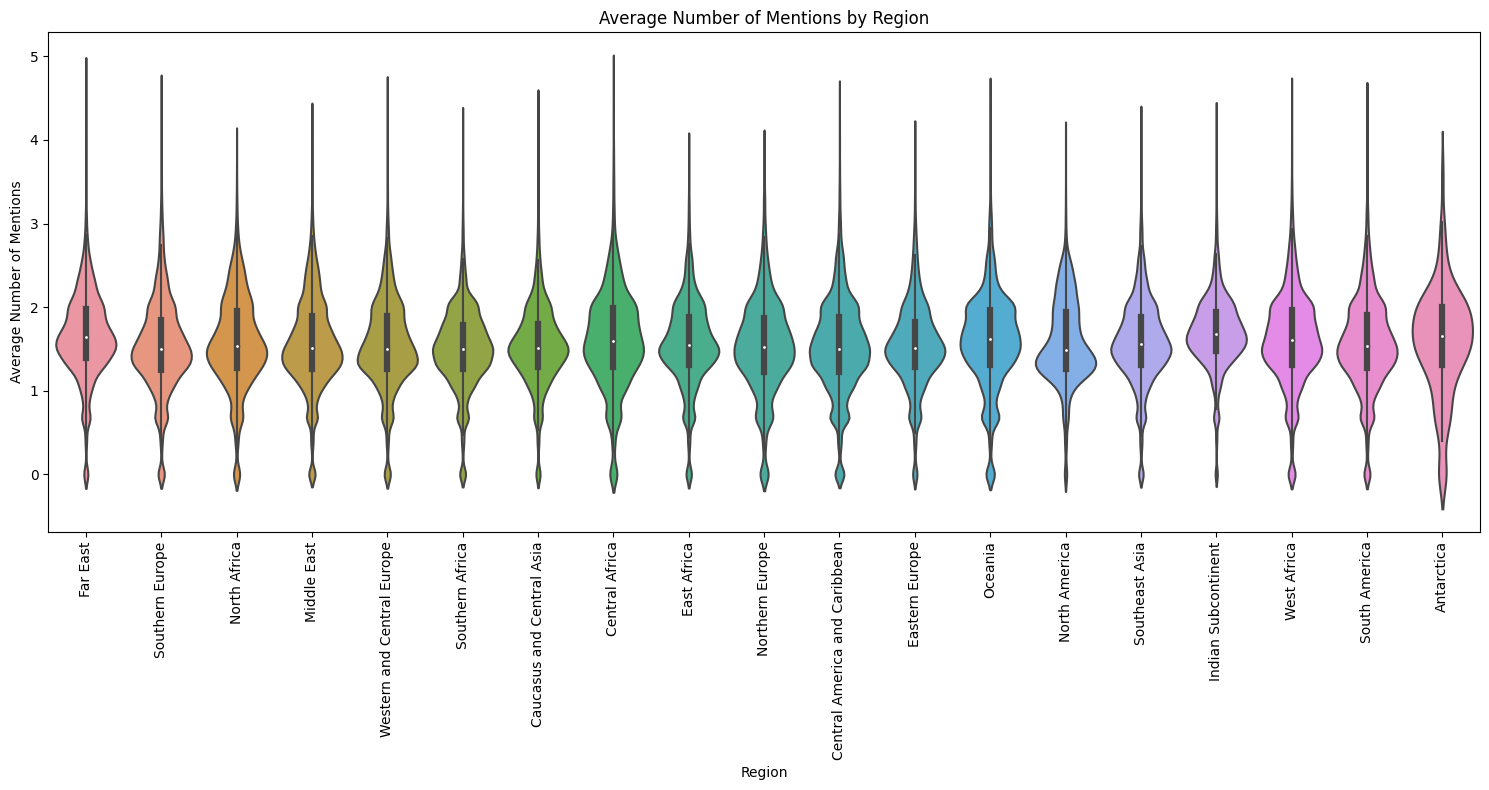

In [22]:
#Violin plot
plt.figure(figsize = (15,8))
sns.violinplot(x = 'Region', y = 'AvgNumMentions', data = df, inner = 'box', scale = 'width')
plt.xticks(rotation = 90)
plt.title('Average Number of Mentions by Region')
plt.ylabel('Average Number of Mentions')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

### Summary

#### Descriptive Statistics
- Across conflict types and severity levels (GoldsteinScale), **mean and median media mentions are very similar**, indicating that higher conflict severity does not necessarily attract more media attention.
- Many events receive **no media coverage**, while a few outliers reach very high mention counts.
- Overall, descriptive statistics confirm that **media attention is largely independent of event severity**.

#### Global Spearman Correlations
- Correlations between **conflict severity** and **media coverage** (AvgNumMentions, SumNumMentions) are **very weak** (≈ -0.02–0.05), indicating minimal influence of severity on coverage.
- **Media coverage strongly correlates with the number of events** (SumEvents, TotalEvents), showing that event quantity drives attention.
- **Average media tone (AvgAvgTone)** shows weak negative correlations with coverage; these should be interpreted cautiously.

#### Continental Analysis
- Across all continents (Africa, Antarctica, Asia, Europe, North America, Oceania, South America):
  - **Severity vs. coverage correlations remain negligible**.
  - **Coverage strongly tracks event counts**.
  - Tone correlations with coverage are weakly negative.
- No continent shows a meaningful departure from the global pattern.

#### Regional Analysis
- Breaking down by region (e.g., Indian Subcontinent, Far East, Middle East, etc.) does **not reveal new patterns**:
  - Severity vs. coverage correlations are consistently very weak.
  - Coverage remains strongly correlated with event counts.
  - Average media tone shows weak to moderate negative correlations.
- Some regions (Indian Subcontinent, Far East, Southern Africa) differ **significantly in mean coverage**, as confirmed by **Welch ANOVA (F(18, 176,413) = 72.88, p < 0.001)**.

#### Post-hoc and Visualization
- **Games-Howell tests** identify specific regional contrasts in AvgNumMentions, consistent with the ANOVA result.
- **Violin plots** illustrate the distribution of coverage by region:
  - Most events have low coverage, with a few high-mention outliers.
  - Regional differences are visually clear, particularly for regions with higher median coverage.

#### Conclusion
- Across **global, continental, and regional levels**, **media coverage is primarily quantity-driven**, not severity-driven.
- **Conflict severity has minimal influence** on the amount of media attention an event receives.
- Regions vary in average coverage, but the underlying pattern—coverage following **event volume** rather than intensity—remains robust.


## 2.4-Countries Most Affected by Severe Conflicts

In this section, we explore the data at a global level using **choropleth maps**. 

We start by examining the number of events per 1,000 inhabitants to make fair comparisons across countries, regardless of population size. This helps us quickly identify countries that have been **more exposed to conflicts** from 1979–2021.

In [23]:
import plotly.express as px

#Aggregate total events per country (original dataset without transformations)
country_events = df_original.groupby('CountryName')['NormalizedEvents1000'].sum().reset_index(name = 'NormalizedEvents1000')

#Standardize country names to match Plotly
name_corrections = {
    "United States of America": "United States",
    "Dem. Rep. Congo": "Democratic Republic of the Congo",
    "Congo": "Republic of the Congo",
    "Côte d'Ivoire": "Ivory Coast",
    "South Korea": "Korea, South",
    "North Korea": "Korea, North",
    "Eswatini": "Swaziland",
    "Burma": "Myanmar",
    "Czechia": "Czech Republic",
    "Fr. S. Antarctic Lands": "French Southern and Antarctic Lands",
    "Solomon Is.": "Solomon Islands",
    "W. Sahara": "Western Sahara",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
    "N. Cyprus": "Northern Cyprus",
    "Falkland Is.": "Falkland Islands"
}

country_events['CountryName'] = country_events['CountryName'].replace(name_corrections)

#Plot choropleth
fig = px.choropleth(
    country_events,
    locations = "CountryName",
    locationmode = "country names",
    color="NormalizedEvents1000",
    hover_name = "CountryName",
    hover_data = ["NormalizedEvents1000"],
    color_continuous_scale = "Reds",
    title = "Conflict Events per 1000 Inhabitants by Country (1979–2021)"
)

fig.show()

In [24]:
#Sort by NormalizedEvents1000 descending and select top 20
top_20_countries = country_events.sort_values(by='NormalizedEvents1000', ascending = False).head(20)

#Display the table
print(top_20_countries)

                CountryName  NormalizedEvents1000
251             Wake Island          14225.358039
81               Gaza Strip          12151.320833
253               West Bank          11189.477462
0               Afghanistan           9611.511740
215               Sri Lanka           9338.591172
212             South Sudan           8464.929678
106                    Iraq           8408.006558
128                 Lebanon           8356.439645
210                 Somalia           8321.608632
48                 Colombia           8150.926809
66              El Salvador           8027.922309
91                Guatemala           7752.433720
181                    Peru           7632.746742
174                Pakistan           7373.613829
182             Philippines           7337.165009
27   Bosnia and Herzegovina           7293.008055
109                  Israel           7284.531661
123                  Kosovo           7275.767062
116          Johnston Atoll           7130.860071


The following choropleth map and table show the **number of severe conflict events per country**, defined as events with a **GoldsteinScale ≤ -9**, from 1979 to 2021. This analysis highlights countries that experienced the most extreme conflict incidents, helping to identify hotspots of severe conflict beyond overall event counts.

In [25]:
#Filter events with GoldsteinScale <= -9 (very severe events)
severe_events = df[df['GoldsteinScale'] <= -9]

#Aggregate number of severe events per country
country_severe_counts = severe_events.groupby('CountryName').size().reset_index(name = 'SevereEventCount')

country_severe_counts['CountryName'] = country_severe_counts['CountryName'].replace(name_corrections)

#Visualization
fig = px.choropleth(
    country_severe_counts,
    locations = 'CountryName',
    locationmode = 'country names',
    color = 'SevereEventCount',
    hover_name = 'CountryName',
    hover_data = ['SevereEventCount'],
    color_continuous_scale = 'Greens',
    title = 'Number of Severe Conflict Events (GoldsteinScale <= -9) by Country (1979–2021)'
)

fig.show()

In [26]:
#Display full table sorted by number of severe events
country_severe_counts_sorted = country_severe_counts.sort_values(by = 'SevereEventCount', ascending = False)
print(country_severe_counts_sorted.head(20))

        CountryName  SevereEventCount
239   United States              1008
106          Israel              1004
238  United Kingdom               969
187          Russia               960
102            Iran               959
73           France               949
125         Lebanon               941
103            Iraq               939
100           India               939
45            China               937
171        Pakistan               930
80          Germany               925
0       Afghanistan               920
208    South Africa               918
231          Turkey               918
107           Italy               913
179     Philippines               907
63            Egypt               902
110           Japan               884
219           Syria               879


To examine whether certain types of severe conflict events (**GoldsteinScale ≤ -9**) are over- or under-represented in specific regions, we computed a **contingency table** of `Region` × `EventRootDescr_short`.  

- **Chi-square test:** Assesses whether the distribution of event types differs significantly across regions. A significant result indicates that some regions experience certain types of severe events more frequently than expected by chance.  
- **Standardized residuals:** Highlight over- or under-represented cells, helping to identify which region-event combinations deviate most from the expected distribution.  
- **Heatmap:** Visualizes these deviations for easy interpretation, where red/blue shading indicates over- or under-representation of event types by region.  

Contingency Table:
 EventRootDescr_short           Assault  Coerce  Fight  Unconv. Violence
Region                                                                 
Antarctica                          72      33    100                 0
Caucasus and Central Asia         2327    1042   1935               411
Central Africa                    1428     601   1250               225
Central America and Caribbean     5208    2323   4601               485
East Africa                       3115    1245   2570               565
Eastern Europe                    2065    1002   1709               347
Far East                          2291    1041   1818               367
Indian Subcontinent               2127     876   1579               382
Middle East                       6042    2443   4564              1161
North Africa                      2072     831   1649               346
North America                      895     365    671               168
Northern Europe                   1893     8

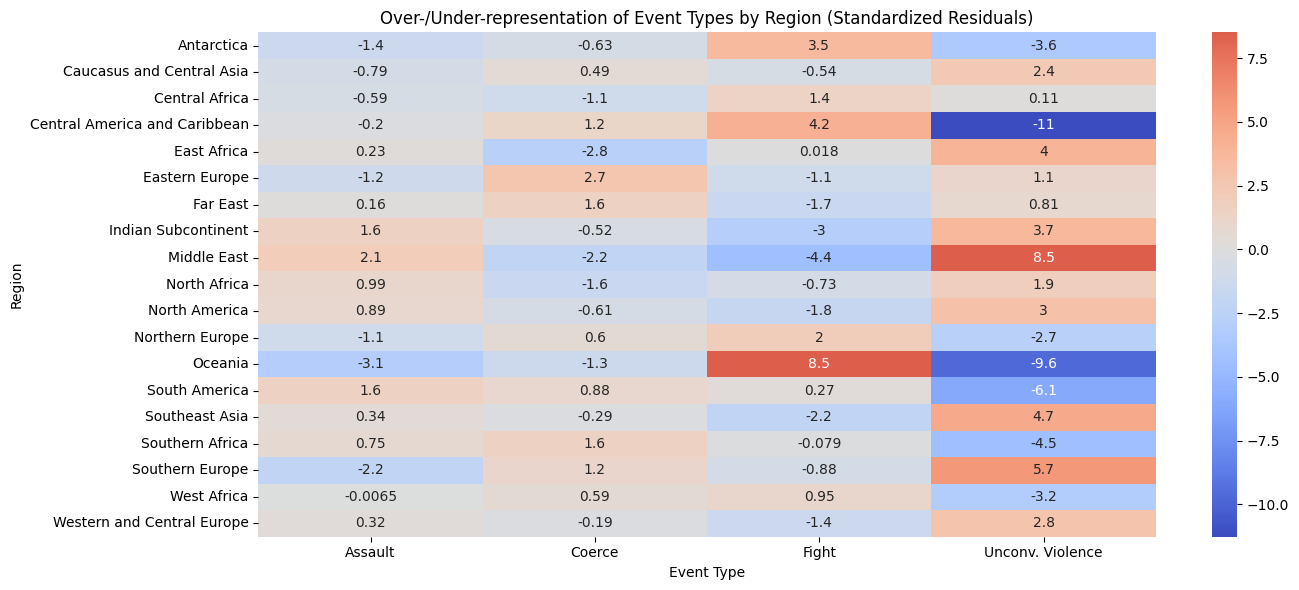

In [27]:
#Filter severe events (GoldsteinScale <= -9)
severe_events = df[df['GoldsteinScale'] <= -9]

#Create a contingency table: Region x Event Type
contingency = pd.crosstab(severe_events['Region'], severe_events['EventRootDescr_short'])
print("Contingency Table:\n", contingency)

#Chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square test results:\nChi2 = {chi2:.2f}, p-value = {p:.4f}, dof = {dof}")

#Compute standardized residuals to find over/under-represented cells
residuals = (contingency - expected) / np.sqrt(expected)
print("\nStandardized residuals:\n", residuals)

#Heatmap of standardized residuals
plt.figure(figsize = (14,6))
sns.heatmap(residuals, annot = True, cmap = 'coolwarm', center = 0)
plt.title("Over-/Under-representation of Event Types by Region (Standardized Residuals)")
plt.ylabel("Region")
plt.xlabel("Event Type")
plt.tight_layout()
plt.show()

The test is highly significant (χ² = 712.76, p < 0.001), indicating that the distribution of event types varies across regions. Some regions show over- or under-representation of specific event types, suggesting that certain types of severe events are more common in some areas than others.

## 2.5-Summary and Limitations

### Conflict Types and Severity over Time

**Conflict Type Composition**  
We analyzed the internal structure of conflict categories:  
- ASSAULT: 13 subtypes  
- COERCE: 12 subtypes  
- FIGHT: 7 subtypes  
- UNCONVENTIONAL MASS VIOLENCE: 3 subtypes  

**Severity Profiles**  
Mean, median, and range of GoldsteinScale reveal distinct intensity patterns:  
- FIGHT: extremely severe, low variance (mean ≈ –9.83)  
- UNCONVENTIONAL MASS VIOLENCE: equally severe (mean ≈ –9.91)  
- ASSAULT: very severe but heterogeneous (mean ≈ –9.36)  
- COERCE: less severe and mixed in nature (mean ≈ –6.52)  

**Subtype-Level Insights**  
- FIGHT and UNCONVENTIONAL MASS VIOLENCE subtypes cluster tightly between –9.5 and –10.  
- ASSAULT spans –8 to –10, COERCE –5 to –9.2.  
This indicates that category-level differences largely reflect internal composition.  

**Temporal Evolution (1979–2021)**  
- Event counts gradually increase until 2014–2016, then decline.  
- COERCE is consistently most frequent; UNCONVENTIONAL MASS VIOLENCE grows fastest relative to baseline.  
- Average severity slightly worsens over time (≈ –8.28 → –8.44), peaking during 2012–2016.  

**Key Takeaways**  
- FIGHT and UNCONVENTIONAL MASS VIOLENCE are the most severe.  
- ASSAULT is severe but variable; COERCE mixes low- and high-intensity actions.  
- Temporal patterns show rising conflicts until mid-2010s, with peak intensity overlapping peak frequency.

### Media Coverage vs. Conflict Severity

**Descriptive Statistics**  
- Mean and median media mentions are similar across conflict severities, indicating severity does not drive attention.  
- Most events receive little to no media coverage; a few extreme cases generate high mentions.  

**Global and Continental Patterns**  
- Spearman correlations between severity and coverage are negligible (≈ -0.02–0.05).  
- Media coverage strongly correlates with the number of events.  
- Average media tone shows weak negative correlations with coverage.  
- Continental and regional analyses confirm these patterns, with minor regional differences in mean coverage.  

**Regional Analysis**  
- Welch ANOVA indicates significant differences in average coverage across regions (F(18,176,413)=72.88, p<0.001).  
- Games-Howell post-hoc tests and violin plots highlight regions with higher median coverage (e.g., Indian Subcontinent, Far East, Southern Africa).  

**Key Takeaways**  
- Media attention is primarily quantity-driven, not severity-driven.  
- Regions vary in average coverage, but underlying patterns remain consistent globally.  

### Countries Most Affected by Severe Conflicts

**Overall Event Exposure**  
- Events per 1,000 inhabitants identify disproportionately affected countries: Wake Island, Gaza Strip, West Bank, Afghanistan, Sri Lanka.  

**Severe Conflict Hotspots (GoldsteinScale ≤ -9)**  
- Countries experiencing the most extreme violence include the United States, Israel, United Kingdom, Russia, Iran, and France.  
- Severe events do not always overlap with overall event counts, highlighting distinct hotspots.  

**Regional Distribution of Severe Event Types**  
- Contingency tables and Chi-square analysis (χ²=712.76, p<0.001) show significant variation in event type distribution across regions.  
- Standardized residuals reveal over- or under-representation of certain event types by region:  
  - Middle East and Central America show higher than expected severe events.  
  - Oceania and South America have mixed patterns.  

**Key Takeaways**  
- Severe conflicts are unevenly distributed globally and regionally.  
- Certain regions experience specific high-intensity event types more frequently.  
- These insights complement earlier analyses by linking conflict severity to geographic hotspots and regional patterns.  

### Limitations

- **Data Coverage:** The dataset only includes recorded and reported conflict events. Minor, unreported, or undetected events are missing, which may underestimate overall conflict exposure in some regions.  
- **Skewed Distributions and Extreme Values:** Many variables (event counts, media mentions, severity) are highly skewed. While transformations were applied for analysis, extreme values may still bias statistical summaries and visualizations.  
- **Media Bias:** Media mentions and tone may not accurately reflect conflict severity due to reporting bias, regional differences in press freedom, or selective coverage.  
- **Categorical Underrepresentation:** Some conflict subtypes and rare event categories are underrepresented, limiting the generalizability of subtype-level analyses.  
- **Temporal Reporting and Geopolitical Changes:** The dataset spans 1979–2021, during which reporting practices and media availability evolved, potentially affecting observed trends over time. Additionally, geopolitical changes (e.g., the dissolution of the USSR into multiple states) may have introduced inconsistencies in country-level data and event attribution.
- **Regional Grouping Challenges:** Some countries span multiple continents (e.g., Russia, Turkey). For analysis purposes, they were assigned to a single region, which may slightly distort regional-level patterns.  
- **Regional Heterogeneity:** Correlations and patterns observed at continental or regional levels may obscure important within-region variability.  
- **Interpretation of Severity:** GoldsteinScale measures event intensity but may not fully capture human impact or long-term consequences of conflicts.  

These limitations highlight areas where caution is required when interpreting the results and provide context for future analyses or modeling efforts.
